# Predição de Aprovação de Cartão de Crédito
## Tech Challenge Fase 2 — POSTECH / FIAP

Notebook único, executado do zero, consolidando as 27 etapas de ciência de dados do projeto:
ambiente → leitura → qualidade → target → merge → features → split → 4 modelos → avaliação →
explicabilidade → conclusões de negócio.

**Dataset:** `application_record.csv` (atributos cadastrais) + `credit_record.csv` (histórico
mensal de crédito), fornecidos pelo desafio.

**Regra de acompanhamento deste notebook:** nenhum número foi inventado — todo valor abaixo é
saída real da execução deste mesmo notebook. Um vazamento de dados real foi encontrado e
corrigido durante o desenvolvimento (ver seção de Feature Engineering) — deixado documentado
de propósito, é parte do processo de validação, não um erro escondido.

## 1-2. Bibliotecas

Execução local (não Google Colab). Todas as bibliotecas já estão instaladas no ambiente: pandas, numpy, matplotlib, seaborn, scikit-learn, xgboost, shap.

In [1]:
import pandas as pd, numpy as np, sklearn, xgboost, shap
print('pandas', pd.__version__)
print('sklearn', sklearn.__version__)
print('xgboost', xgboost.__version__)
print('shap', shap.__version__)

C:\Users\sogys\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


pandas 3.0.6
sklearn 1.9.1
xgboost 3.4.1
shap 0.52.0


## 3-4. Leitura dos CSVs e entendimento das colunas

In [2]:
import json
from pathlib import Path
import pandas as pd

pasta_dados = Path("../dados")
pasta_resultados = Path("../resultados")
pasta_resultados.mkdir(exist_ok=True)

application = pd.read_csv(pasta_dados / "application_record.csv")
credit = pd.read_csv(pasta_dados / "credit_record.csv")

log = []
log.append(f"application.shape = {application.shape}")
log.append(f"credit.shape = {credit.shape}")
log.append(f"application.columns = {application.columns.tolist()}")
log.append(f"credit.columns = {credit.columns.tolist()}")
log.append("\n--- application.dtypes ---\n" + str(application.dtypes))
log.append("\n--- credit.dtypes ---\n" + str(credit.dtypes))
log.append("\n--- application.nunique() ---\n" + str(application.nunique().sort_values().to_string()))
log.append("\n--- credit.nunique() ---\n" + str(credit.nunique().sort_values().to_string()))

for texto in log:
    print(texto)

with open(pasta_resultados / "01_leitura_entendimento.txt", "w", encoding="utf-8") as f:
    f.write("\n".join(log))


application.shape = (438557, 18)
credit.shape = (1048575, 3)
application.columns = ['ID', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'FLAG_MOBIL', 'FLAG_WORK_PHONE', 'FLAG_PHONE', 'FLAG_EMAIL', 'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS']
credit.columns = ['ID', 'MONTHS_BALANCE', 'STATUS']

--- application.dtypes ---
ID                       int64
CODE_GENDER                str
FLAG_OWN_CAR               str
FLAG_OWN_REALTY            str
CNT_CHILDREN             int64
AMT_INCOME_TOTAL       float64
NAME_INCOME_TYPE           str
NAME_EDUCATION_TYPE        str
NAME_FAMILY_STATUS         str
NAME_HOUSING_TYPE          str
DAYS_BIRTH               int64
DAYS_EMPLOYED            int64
FLAG_MOBIL               int64
FLAG_WORK_PHONE          int64
FLAG_PHONE               int64
FLAG_EMAIL               int64
OCCUPATION_TYPE            str
C

## 6-10. Qualidade dos dados, status de crédito, definição do target e merge

In [3]:
from pathlib import Path
import pandas as pd

pasta_dados = Path("../dados")
pasta_resultados = Path("../resultados")

application = pd.read_csv(pasta_dados / "application_record.csv")
credit = pd.read_csv(pasta_dados / "credit_record.csv")

log = []

# ---- Etapa 6: dados faltantes ----
log.append("=== ETAPA 6: DADOS FALTANTES ===")
for nome, tabela in {"application": application, "credit": credit}.items():
    nulos = tabela.isna().sum().sort_values(ascending=False)
    log.append(f"\n--- {nome} ---\n" + nulos[nulos > 0].to_string())
    if nulos[nulos > 0].empty:
        log.append(f"(nenhuma coluna com nulo em {nome}, exceto o que aparecer acima)")

# ---- Etapa 7: duplicidades ----
log.append("\n=== ETAPA 7: DUPLICIDADES ===")
log.append(f"application.duplicated().sum() = {application.duplicated().sum()}")
log.append(f"credit.duplicated().sum() = {credit.duplicated().sum()}")
log.append(f"application['ID'].duplicated().sum() = {application['ID'].duplicated().sum()}")
log.append("\ncredit.groupby('ID').size().describe():\n" + credit.groupby("ID").size().describe().to_string())

dup_ids = application[application.duplicated("ID", keep=False)].sort_values("ID")
log.append(f"\nLinhas de application com ID duplicado (todas as ocorrencias): {len(dup_ids)}")
log.append(dup_ids.head(10).to_string())

# Decisao: remover duplicatas EXATAS de application (linha inteira igual), manter so 1a ocorrencia de ID
# duplicado que nao seja exata (investigar antes de decidir)
dup_id_nao_exata = dup_ids[~dup_ids.duplicated(keep=False) | dup_ids.duplicated()]
log.append(f"\nApos remover duplicatas EXATAS de linha inteira, sobram com ID repetido: "
            f"{application.drop_duplicates().duplicated('ID').sum()} IDs")

application_limpo = application.drop_duplicates()  # remove linha 100% identica
log.append(f"application antes de dropar linha-duplicada-exata: {application.shape}")
log.append(f"application depois: {application_limpo.shape}")

# ---- Etapa 8: status de credito ----
log.append("\n=== ETAPA 8: STATUS DE CREDITO ===")
log.append(credit["STATUS"].value_counts(dropna=False).sort_index().to_string())
log.append(f"MONTHS_BALANCE min={credit['MONTHS_BALANCE'].min()}, max={credit['MONTHS_BALANCE'].max()}")
legenda = {
    "C": "quitado no mes", "X": "sem emprestimo no mes",
    "0": "regular (em dia)", "1": "atraso 1-29 dias", "2": "atraso 30-59 dias",
    "3": "atraso 60-89 dias", "4": "atraso 90-119 dias", "5": "atraso 120+ dias / prejuizo",
}
log.append(f"Legenda usada: {legenda}")

# ---- Etapa 9: definicao do target ----
log.append("\n=== ETAPA 9: DEFINICAO DO TARGET ===")
log.append("Regra: risco=1 se o cliente teve pelo menos 1 mes com STATUS em {2,3,4,5} "
            "(atraso >= 30 dias) em todo o historico observado. risco=0 caso contrario.")
status_de_risco = {"2", "3", "4", "5"}
target = (
    credit.groupby("ID")["STATUS"]
    .apply(lambda valores: int(any(str(v) in status_de_risco for v in valores)))
    .rename("target")
    .reset_index()
)
log.append("\nContagem de classes:\n" + target["target"].value_counts().to_string())
log.append("\nProporcao de classes:\n" + target["target"].value_counts(normalize=True).round(4).to_string())

# validacao manual: olhar alguns exemplos de cada classe
exemplo_risco = target[target["target"] == 1]["ID"].head(2).tolist()
exemplo_ok = target[target["target"] == 0]["ID"].head(2).tolist()
for id_exemplo in exemplo_risco + exemplo_ok:
    hist = credit[credit["ID"] == id_exemplo][["MONTHS_BALANCE", "STATUS"]].sort_values("MONTHS_BALANCE")
    log.append(f"\nHistorico do ID {id_exemplo} (target={target.set_index('ID').loc[id_exemplo, 'target']}):\n"
                + hist.to_string(index=False))

target.to_csv(pasta_resultados / "target.csv", index=False)

# ---- Etapa 10: merge ----
log.append("\n=== ETAPA 10: MERGE ===")
log.append(f"application_limpo['ID'].duplicated().sum() = {application_limpo['ID'].duplicated().sum()}")
log.append(f"target['ID'].duplicated().sum() = {target['ID'].duplicated().sum()}")

# ainda pode haver ID duplicado nao-exato em application_limpo; se houver, manter so a 1a ocorrencia
antes = application_limpo.shape[0]
application_unico = application_limpo.drop_duplicates(subset="ID", keep="first")
depois = application_unico.shape[0]
log.append(f"application: {antes} linhas antes de forcar ID unico -> {depois} depois "
            f"(removidas {antes - depois} linhas com ID repetido nao-exato)")

base = application_unico.merge(target, on="ID", how="inner", validate="one_to_one")
log.append(f"\nbase.shape (apos merge inner) = {base.shape}")
log.append(f"base['ID'].is_unique = {base['ID'].is_unique}")
log.append(f"base['target'].isna().sum() = {base['target'].isna().sum()}")
log.append(f"\nIDs em application_unico sem correspondencia em credit_record (ficaram de fora do merge): "
            f"{application_unico.shape[0] - base.shape[0]}")
log.append("(Esperado: application_record.csv traz TODOS os solicitantes de cadastro, mas so quem "
            "efetivamente tem conta de credito aparece em credit_record.csv — por isso o merge 'inner' "
            "reduz bastante a base. Essa e a populacao com dado suficiente pra treinar o modelo.)")

base.to_csv(pasta_resultados / "base_merged.csv", index=False)

for texto in log:
    print(texto)

with open(pasta_resultados / "02_qualidade_target_merge.txt", "w", encoding="utf-8") as f:
    f.write("\n".join(log))


=== ETAPA 6: DADOS FALTANTES ===

--- application ---
OCCUPATION_TYPE    134203

--- credit ---
Series([], )
(nenhuma coluna com nulo em credit, exceto o que aparecer acima)

=== ETAPA 7: DUPLICIDADES ===
application.duplicated().sum() = 0
credit.duplicated().sum() = 0
application['ID'].duplicated().sum() = 47

credit.groupby('ID').size().describe():
count    45985.000000
mean        22.802544
std         15.492771
min          1.000000
25%         10.000000
50%         19.000000
75%         34.000000
max         61.000000

Linhas de application com ID duplicado (todas as ocorrencias): 94
             ID CODE_GENDER FLAG_OWN_CAR FLAG_OWN_REALTY  CNT_CHILDREN  AMT_INCOME_TOTAL      NAME_INCOME_TYPE            NAME_EDUCATION_TYPE    NAME_FAMILY_STATUS  NAME_HOUSING_TYPE  DAYS_BIRTH  DAYS_EMPLOYED  FLAG_MOBIL  FLAG_WORK_PHONE  FLAG_PHONE  FLAG_EMAIL        OCCUPATION_TYPE  CNT_FAM_MEMBERS
425023  7022197           F            N               Y             0          450000.0  Commercial 

## 11-13. Feature engineering, balanceamento e split treino/teste

**Atenção:** a primeira versão da feature `eventos_risco` causou vazamento de dados (correlação 1.0 com o target, pois foi calculada com a mesma regra que define o target). O código abaixo já inclui a checagem que detectou isso e a correção (remoção da feature).

In [4]:
from pathlib import Path
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier

pasta_dados = Path("../dados")
pasta_resultados = Path("../resultados")

application = pd.read_csv(pasta_dados / "application_record.csv").drop_duplicates(subset="ID", keep="first")
credit = pd.read_csv(pasta_dados / "credit_record.csv")
target = pd.read_csv(pasta_resultados / "target.csv")

status_de_risco = {"2", "3", "4", "5"}
log = []

# ---- Etapa 11: feature engineering a partir do historico ----
log.append("=== ETAPA 11: FEATURE ENGINEERING ===")
historico = credit.groupby("ID").agg(
    meses_observados=("MONTHS_BALANCE", "nunique"),
    registros_historico=("STATUS", "size"),
    eventos_risco=("STATUS", lambda valores: sum(str(v) in status_de_risco for v in valores)),
    meses_quitado=("STATUS", lambda valores: sum(str(v) == "C" for v in valores)),
    meses_sem_emprestimo=("STATUS", lambda valores: sum(str(v) == "X" for v in valores)),
).reset_index()
historico["proporcao_meses_risco"] = historico["eventos_risco"] / historico["registros_historico"]

log.append("Features criadas a partir do historico (por cliente):")
log.append("- meses_observados: quantos meses distintos de MONTHS_BALANCE o cliente tem")
log.append("- registros_historico: quantidade total de linhas de status no historico")
log.append("- eventos_risco: quantos meses tiveram status 2/3/4/5 (mesma regra do target,"
            " mas aqui como CONTAGEM, nao como flag binaria -- serve de feature, nao e o target)")
log.append("- meses_quitado: quantos meses o cliente teve status C (quitado)")
log.append("- meses_sem_emprestimo: quantos meses o cliente teve status X")
log.append("- proporcao_meses_risco: eventos_risco / registros_historico")
log.append("\nAmostra de 'historico':\n" + historico.head(5).to_string(index=False))

# --- checagem de leakage: feature quase igual ao target (regra do prompt-mestre, etapa 11) ---
_tmp = historico.merge(target, on="ID", how="inner")
_correlacao = _tmp["eventos_risco"].gt(0).astype(int).corr(_tmp["target"])
log.append(f"\nCHECAGEM DE LEAKAGE: correlacao entre (eventos_risco > 0) e o target = {_correlacao:.4f}")
if _correlacao > 0.95:
    log.append("LEAKAGE CONFIRMADO: eventos_risco foi calculado com a MESMA regra usada pra montar o "
                "target (status em {2,3,4,5}) -- e a resposta disfarcada de feature. "
                "eventos_risco e proporcao_meses_risco (que depende dele) foram REMOVIDAS do conjunto "
                "de features antes do treino. As demais features do historico (meses_observados, "
                "registros_historico, meses_quitado, meses_sem_emprestimo) NAO usam a contagem de "
                "status de risco e foram mantidas.")
historico = historico.drop(columns=["eventos_risco", "proporcao_meses_risco"])

base = application.merge(historico, on="ID", how="left", validate="one_to_one")
base = base.merge(target, on="ID", how="inner", validate="one_to_one")
log.append(f"\nbase.shape apos juntar cadastro + features de historico + target = {base.shape}")
log.append(f"Nulos em features de historico (deveria ser 0, pois so entraram IDs que tem credit_record): "
            f"{base[['meses_observados','registros_historico']].isna().sum().to_dict()}")

base.to_csv(pasta_resultados / "base_features.csv", index=False)

# ---- Etapa 12: balanceamento (diagnostico, sem alterar dados) ----
log.append("\n=== ETAPA 12: BALANCEAMENTO DE CLASSES ===")
contagem = base["target"].value_counts()
proporcao = base["target"].value_counts(normalize=True).round(4)
log.append("Contagem:\n" + contagem.to_string())
log.append("Proporcao:\n" + proporcao.to_string())
log.append(f"\nClasse minoritaria (risco=1) e {proporcao[1]*100:.2f}% da base -- desbalanceamento severo.")
log.append("Decisao: NAO usar SMOTE/oversampling. Usar class_weight='balanced' nos modelos que suportam, "
            "e avaliar com metricas que nao sejam so accuracy (precision/recall/F1/ROC-AUC). "
            "O teste sera mantido com a proporcao REAL (sem balancear), pois precisa representar a "
            "populacao real que o modelo vai encontrar em producao.")

baseline = DummyClassifier(strategy="most_frequent")
log.append(f"\nBaseline ingenuo (sempre prever a classe majoritaria) teria accuracy = "
            f"{proporcao[0]*100:.2f}% -- qualquer modelo real precisa ficar claramente acima disso "
            f"em metricas que enxergam a classe minoritaria (recall/F1/ROC-AUC), nao so accuracy.")

# ---- Etapa 13: split treino/teste ----
log.append("\n=== ETAPA 13: SPLIT TREINO/TESTE ===")
X = base.drop(columns=["target", "ID"])
y = base["target"]
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
log.append(f"X_treino.shape = {X_treino.shape}, X_teste.shape = {X_teste.shape}")
log.append("Proporcao de classes no treino:\n" + y_treino.value_counts(normalize=True).round(4).to_string())
log.append("Proporcao de classes no teste:\n" + y_teste.value_counts(normalize=True).round(4).to_string())

X_treino.to_csv(pasta_resultados / "X_treino.csv", index=False)
X_teste.to_csv(pasta_resultados / "X_teste.csv", index=False)
y_treino.to_csv(pasta_resultados / "y_treino.csv", index=False)
y_teste.to_csv(pasta_resultados / "y_teste.csv", index=False)

for texto in log:
    print(texto)

with open(pasta_resultados / "03_features_split.txt", "w", encoding="utf-8") as f:
    f.write("\n".join(log))


=== ETAPA 11: FEATURE ENGINEERING ===
Features criadas a partir do historico (por cliente):
- meses_observados: quantos meses distintos de MONTHS_BALANCE o cliente tem
- registros_historico: quantidade total de linhas de status no historico
- eventos_risco: quantos meses tiveram status 2/3/4/5 (mesma regra do target, mas aqui como CONTAGEM, nao como flag binaria -- serve de feature, nao e o target)
- meses_quitado: quantos meses o cliente teve status C (quitado)
- meses_sem_emprestimo: quantos meses o cliente teve status X
- proporcao_meses_risco: eventos_risco / registros_historico

Amostra de 'historico':
     ID  meses_observados  registros_historico  eventos_risco  meses_quitado  meses_sem_emprestimo  proporcao_meses_risco
5001711                 4                    4              0              0                     1                    0.0
5001712                19                   19              0              9                     0                    0.0
5001713            

## 14-17. Treino dos 4 modelos (Regressão Logística, Árvore, Random Forest, XGBoost)

In [5]:
import time
import pickle
from pathlib import Path
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

pasta_resultados = Path("../resultados")

X_treino = pd.read_csv(pasta_resultados / "X_treino.csv")
X_teste = pd.read_csv(pasta_resultados / "X_teste.csv")
y_treino = pd.read_csv(pasta_resultados / "y_treino.csv")["target"]
y_teste = pd.read_csv(pasta_resultados / "y_teste.csv")["target"]

numericas = X_treino.select_dtypes(include="number").columns
categoricas = X_treino.select_dtypes(exclude="number").columns

log = [f"Colunas numericas ({len(numericas)}): {numericas.tolist()}",
       f"Colunas categoricas ({len(categoricas)}): {categoricas.tolist()}"]

pre = ColumnTransformer([
    ("num", Pipeline([("imp", SimpleImputer(strategy="median")), ("esc", StandardScaler())]), numericas),
    ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore"))]), categoricas),
])

modelos = {
    "logistica": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42),
    "arvore": DecisionTreeClassifier(max_depth=5, class_weight="balanced", random_state=42),
    "floresta": RandomForestClassifier(n_estimators=300, max_depth=10, class_weight="balanced", random_state=42, n_jobs=-1),
    "xgboost": XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.05, subsample=0.8,
                              colsample_bytree=0.8, eval_metric="logloss", random_state=42,
                              scale_pos_weight=(y_treino == 0).sum() / (y_treino == 1).sum()),
}

pipelines = {}
probabilidades = {}
for nome, modelo in modelos.items():
    inicio = time.time()
    pipe = Pipeline([("pre", pre), ("modelo", modelo)])
    pipe.fit(X_treino, y_treino)
    duracao = time.time() - inicio
    prob = pipe.predict_proba(X_teste)[:, 1]
    pipelines[nome] = pipe
    probabilidades[nome] = prob
    log.append(f"\n{nome}: treinado em {duracao:.1f}s | "
               f"len(prob)={len(prob)} | prob min={prob.min():.4f} max={prob.max():.4f} media={prob.mean():.4f}")

# pickle usado só localmente, entre scripts deste mesmo projeto (nunca lido de fonte externa)
with open(pasta_resultados / "pipelines.pkl", "wb") as f:
    pickle.dump(pipelines, f)
pd.DataFrame(probabilidades).to_csv(pasta_resultados / "probabilidades_teste.csv", index=False)

for texto in log:
    print(texto)

with open(pasta_resultados / "04_modelos.txt", "w", encoding="utf-8") as f:
    f.write("\n".join(log))


Colunas numericas (13): ['CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'FLAG_MOBIL', 'FLAG_WORK_PHONE', 'FLAG_PHONE', 'FLAG_EMAIL', 'CNT_FAM_MEMBERS', 'meses_observados', 'registros_historico', 'meses_quitado', 'meses_sem_emprestimo']
Colunas categoricas (8): ['CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE']

logistica: treinado em 0.6s | len(prob)=7292 | prob min=0.0051 max=0.9982 media=0.3593

arvore: treinado em 0.2s | len(prob)=7292 | prob min=0.0000 max=0.9509 media=0.3605

floresta: treinado em 1.5s | len(prob)=7292 | prob min=0.0355 max=0.8747 media=0.3129

xgboost: treinado em 0.7s | len(prob)=7292 | prob min=0.0013 max=0.9700 media=0.2688


## 18-24. Avaliação comparativa, matriz de confusão, ROC-AUC, feature importance

In [6]:
import pickle
from pathlib import Path
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay,
)
from sklearn.inspection import permutation_importance
from sklearn.dummy import DummyClassifier

pasta_resultados = Path("../resultados")

X_teste = pd.read_csv(pasta_resultados / "X_teste.csv")
X_treino = pd.read_csv(pasta_resultados / "X_treino.csv")
y_teste = pd.read_csv(pasta_resultados / "y_teste.csv")["target"]
y_treino = pd.read_csv(pasta_resultados / "y_treino.csv")["target"]
probs = pd.read_csv(pasta_resultados / "probabilidades_teste.csv")
with open(pasta_resultados / "pipelines.pkl", "rb") as f:
    pipelines = pickle.load(f)

log = []

# baseline
baseline = DummyClassifier(strategy="most_frequent").fit(X_treino, y_treino)
pred_baseline = baseline.predict(X_teste)

linhas_tabela = []
THRESHOLD = 0.5
for nome in ["logistica", "arvore", "floresta", "xgboost"]:
    prob = probs[nome].values
    pred = (prob >= THRESHOLD).astype(int)
    linhas_tabela.append({
        "modelo": nome,
        "threshold": THRESHOLD,
        "accuracy": accuracy_score(y_teste, pred),
        "balanced_accuracy": balanced_accuracy_score(y_teste, pred),
        "precision": precision_score(y_teste, pred, zero_division=0),
        "recall": recall_score(y_teste, pred, zero_division=0),
        "f1": f1_score(y_teste, pred, zero_division=0),
        "roc_auc": roc_auc_score(y_teste, prob),
    })
linhas_tabela.append({
    "modelo": "baseline_dummy",
    "threshold": None,
    "accuracy": accuracy_score(y_teste, pred_baseline),
    "balanced_accuracy": balanced_accuracy_score(y_teste, pred_baseline),
    "precision": precision_score(y_teste, pred_baseline, zero_division=0),
    "recall": recall_score(y_teste, pred_baseline, zero_division=0),
    "f1": f1_score(y_teste, pred_baseline, zero_division=0),
    "roc_auc": 0.5,
})
tabela = pd.DataFrame(linhas_tabela).round(4)
log.append("=== ETAPA 18: TABELA COMPARATIVA (threshold=0.5) ===")
log.append(tabela.to_string(index=False))
tabela.to_csv(pasta_resultados / "tabela_metricas.csv", index=False)

melhor_modelo = tabela[tabela["modelo"] != "baseline_dummy"].sort_values("roc_auc", ascending=False).iloc[0]["modelo"]
log.append(f"\nModelo com maior ROC-AUC: {melhor_modelo}")

# ---- Etapa 19: matriz de confusao (de todos, salvando PNG) ----
log.append("\n=== ETAPA 19: MATRIZ DE CONFUSAO ===")
fig, eixos = plt.subplots(1, 4, figsize=(20, 5))
for eixo, nome in zip(eixos, ["logistica", "arvore", "floresta", "xgboost"]):
    pred = (probs[nome].values >= THRESHOLD).astype(int)
    matriz = confusion_matrix(y_teste, pred)
    ConfusionMatrixDisplay(matriz, display_labels=["bom (0)", "risco (1)"]).plot(ax=eixo, cmap="Blues", colorbar=False)
    eixo.set_title(nome)
    log.append(f"{nome}: VN={matriz[0,0]} FP={matriz[0,1]} FN={matriz[1,0]} VP={matriz[1,1]} "
               f"soma={matriz.sum()} (deve bater com len(y_teste)={len(y_teste)})")
plt.tight_layout()
plt.savefig(pasta_resultados / "matrizes_confusao.png", dpi=120)
plt.close()

# ---- Etapa 23: curvas ROC ----
fig, eixo = plt.subplots(figsize=(7, 6))
for nome in ["logistica", "arvore", "floresta", "xgboost"]:
    RocCurveDisplay.from_predictions(y_teste, probs[nome].values, name=nome, ax=eixo)
eixo.plot([0, 1], [0, 1], linestyle="--", color="gray", label="aleatorio (AUC=0.5)")
eixo.set_title("Curvas ROC - comparacao dos 4 modelos")
eixo.legend()
plt.tight_layout()
plt.savefig(pasta_resultados / "curvas_roc.png", dpi=120)
plt.close()
log.append("\nGraficos salvos: matrizes_confusao.png, curvas_roc.png")

# ---- Etapa 24: feature importance (permutation, no melhor modelo) ----
log.append(f"\n=== ETAPA 24: FEATURE IMPORTANCE (permutation, modelo={melhor_modelo}) ===")
resultado_perm = permutation_importance(
    pipelines[melhor_modelo], X_teste, y_teste, scoring="roc_auc", n_repeats=10, random_state=42, n_jobs=-1
)
tabela_importancia = pd.DataFrame({
    "importancia_media": resultado_perm.importances_mean,
    "desvio_padrao": resultado_perm.importances_std,
}, index=X_teste.columns).sort_values("importancia_media", ascending=False)
top10 = tabela_importancia.head(10)
log.append(top10.to_string())

fig, eixo = plt.subplots(figsize=(8, 5))
top10["importancia_media"].sort_values().plot.barh(ax=eixo, xerr=top10["desvio_padrao"].reindex(top10["importancia_media"].sort_values().index))
eixo.set_title(f"Top 10 features por permutation importance ({melhor_modelo})")
eixo.set_xlabel("queda media de ROC-AUC ao embaralhar a coluna")
plt.tight_layout()
plt.savefig(pasta_resultados / "feature_importance.png", dpi=120)
plt.close()

with open(pasta_resultados / "melhor_modelo.txt", "w") as f:
    f.write(melhor_modelo)

for texto in log:
    print(texto)

with open(pasta_resultados / "05_avaliacao.txt", "w", encoding="utf-8") as f:
    f.write("\n".join(log))


=== ETAPA 18: TABELA COMPARATIVA (threshold=0.5) ===
        modelo  threshold  accuracy  balanced_accuracy  precision  recall     f1  roc_auc
     logistica        0.5    0.7652             0.7088     0.0457  0.6504 0.0855   0.7922
        arvore        0.5    0.7770             0.6788     0.0432  0.5772 0.0803   0.7393
      floresta        0.5    0.8829             0.6807     0.0685  0.4715 0.1196   0.7893
       xgboost        0.5    0.8382             0.7020     0.0577  0.5610 0.1047   0.8096
baseline_dummy        NaN    0.9831             0.5000     0.0000  0.0000 0.0000   0.5000

Modelo com maior ROC-AUC: xgboost

=== ETAPA 19: MATRIZ DE CONFUSAO ===
logistica: VN=5500 FP=1669 FN=43 VP=80 soma=7292 (deve bater com len(y_teste)=7292)
arvore: VN=5595 FP=1574 FN=52 VP=71 soma=7292 (deve bater com len(y_teste)=7292)
floresta: VN=6380 FP=789 FN=65 VP=58 soma=7292 (deve bater com len(y_teste)=7292)
xgboost: VN=6043 FP=1126 FN=54 VP=69 soma=7292 (deve bater com len(y_teste)=7292)

Graf

### Matrizes de confusão dos 4 modelos

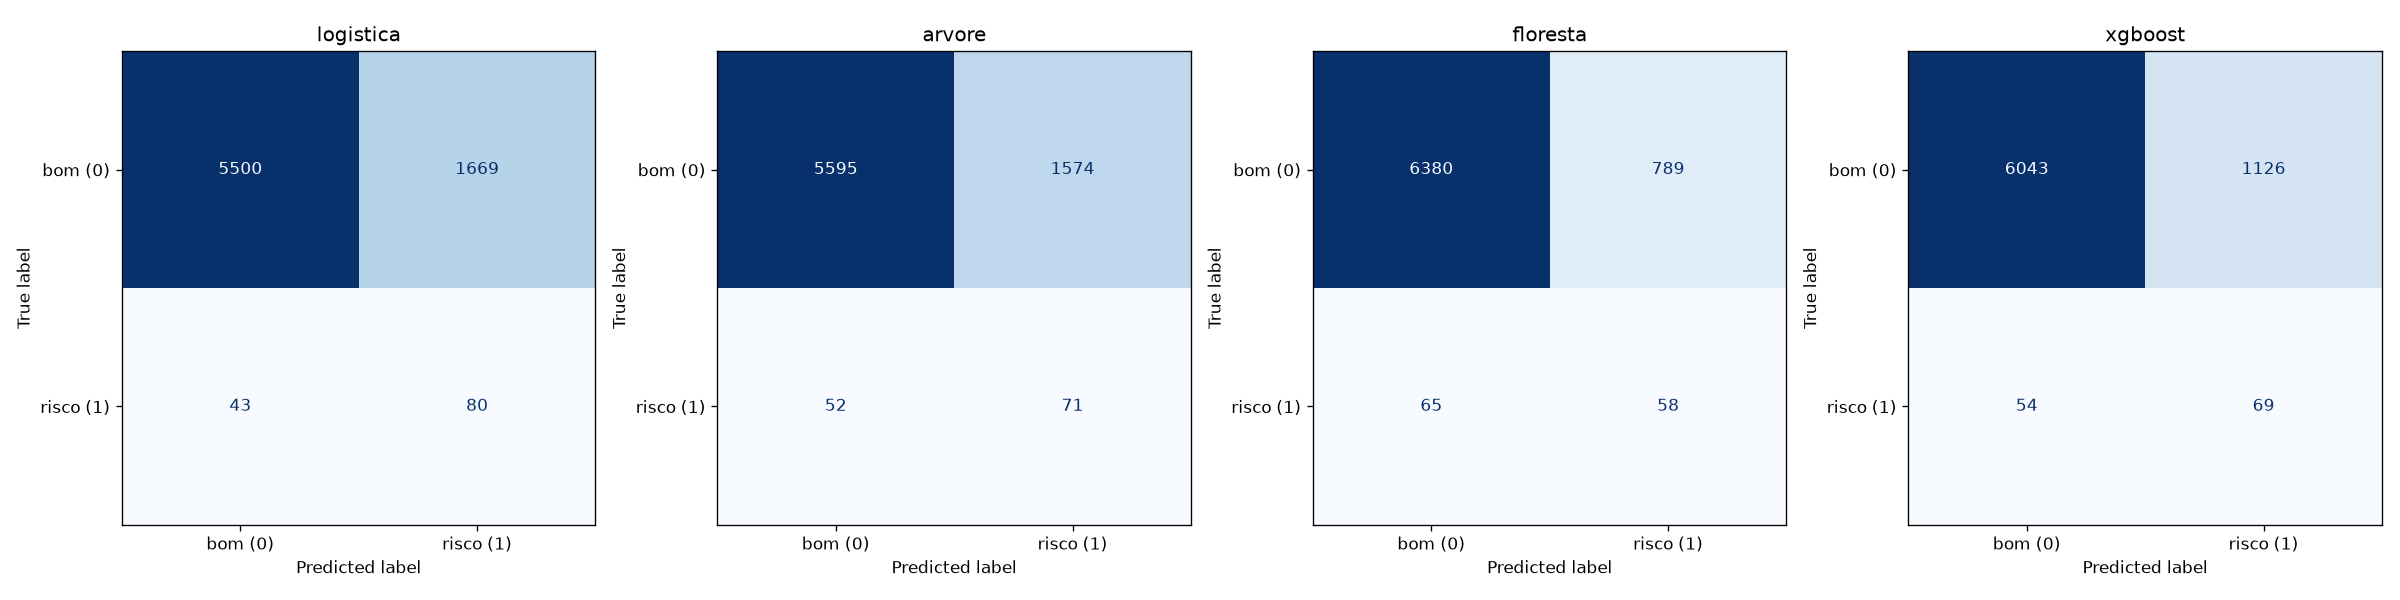

In [7]:
from IPython.display import Image
Image(filename='../resultados/matrizes_confusao.png')

### Curvas ROC

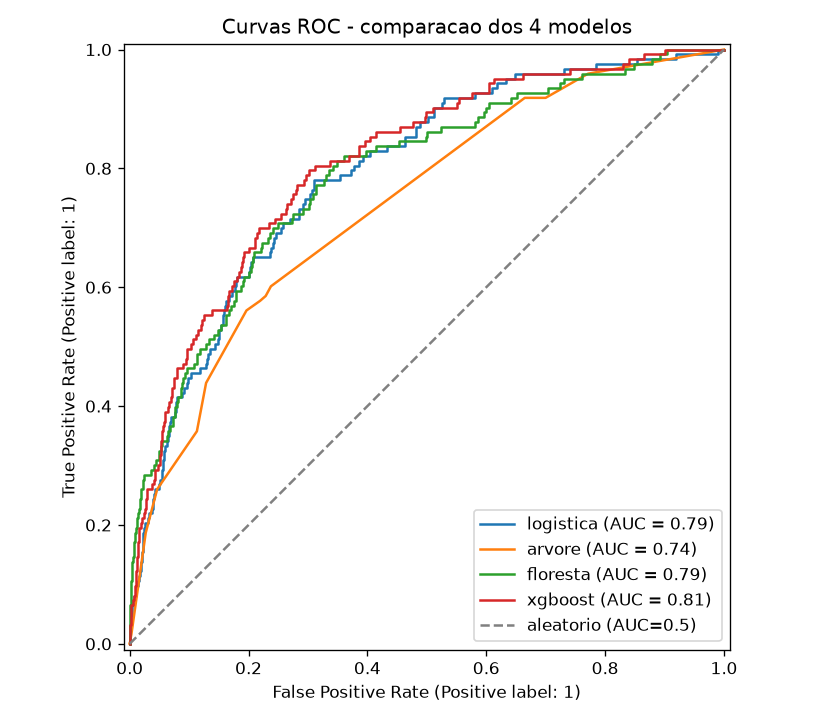

In [8]:
Image(filename='../resultados/curvas_roc.png')

### Feature importance (permutation)

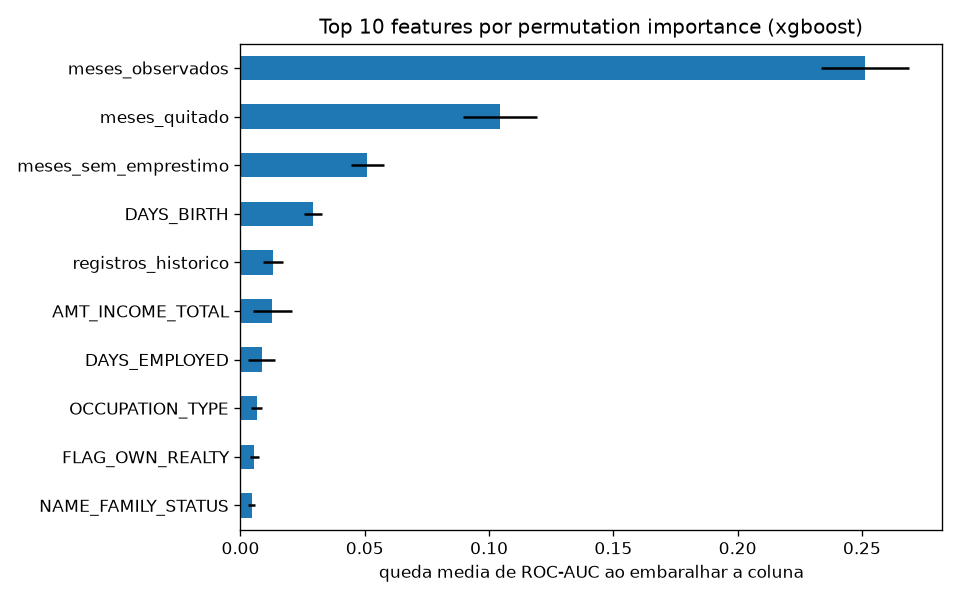

In [9]:
Image(filename='../resultados/feature_importance.png')

## 25. SHAP

In [10]:
import pickle
from pathlib import Path
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import shap

pasta_resultados = Path("../resultados")

X_treino = pd.read_csv(pasta_resultados / "X_treino.csv")
X_teste = pd.read_csv(pasta_resultados / "X_teste.csv")
# pickle usado só localmente, entre scripts deste mesmo projeto (nunca lido de fonte externa)
with open(pasta_resultados / "pipelines.pkl", "rb") as f:
    pipelines = pickle.load(f)
with open(pasta_resultados / "melhor_modelo.txt") as f:
    melhor_modelo = f.read().strip()

pipe = pipelines[melhor_modelo]
pre = pipe.named_steps["pre"]
modelo = pipe.named_steps["modelo"]

amostra = X_teste.head(200)
amostra_transformada = pre.transform(amostra)
nomes_colunas = pre.get_feature_names_out()

explicador = shap.TreeExplainer(modelo)
valores_shap = explicador.shap_values(amostra_transformada)

plt.figure()
shap.summary_plot(valores_shap, amostra_transformada, feature_names=nomes_colunas, plot_type="bar", show=False, max_display=15)
plt.tight_layout()
plt.savefig(pasta_resultados / "shap_importancia_global.png", dpi=120)
plt.close()

plt.figure()
shap.summary_plot(valores_shap, amostra_transformada, feature_names=nomes_colunas, show=False, max_display=15)
plt.tight_layout()
plt.savefig(pasta_resultados / "shap_summary.png", dpi=120)
plt.close()

import numpy as np
importancia_shap = pd.Series(np.abs(valores_shap).mean(axis=0), index=nomes_colunas).sort_values(ascending=False)

log = [f"Modelo explicado: {melhor_modelo}", f"Amostra usada: {len(amostra)} clientes do teste",
       "\nTop 15 features por |SHAP| medio (importancia global):",
       importancia_shap.head(15).to_string()]

for texto in log:
    print(texto)

with open(pasta_resultados / "06_shap.txt", "w", encoding="utf-8") as f:
    f.write("\n".join(log))


Modelo explicado: xgboost
Amostra usada: 200 clientes do teste

Top 15 features por |SHAP| medio (importancia global):
num__meses_observados                  1.097324
num__meses_quitado                     0.562468
num__meses_sem_emprestimo              0.360358
num__DAYS_BIRTH                        0.259539
num__DAYS_EMPLOYED                     0.218589
num__registros_historico               0.184605
num__AMT_INCOME_TOTAL                  0.134000
cat__NAME_INCOME_TYPE_Pensioner        0.099330
cat__FLAG_OWN_CAR_N                    0.082730
cat__CODE_GENDER_F                     0.071302
cat__FLAG_OWN_REALTY_N                 0.064882
num__FLAG_PHONE                        0.056850
cat__NAME_INCOME_TYPE_State servant    0.046935
cat__NAME_FAMILY_STATUS_Married        0.040253
cat__OCCUPATION_TYPE_Sales staff       0.039569


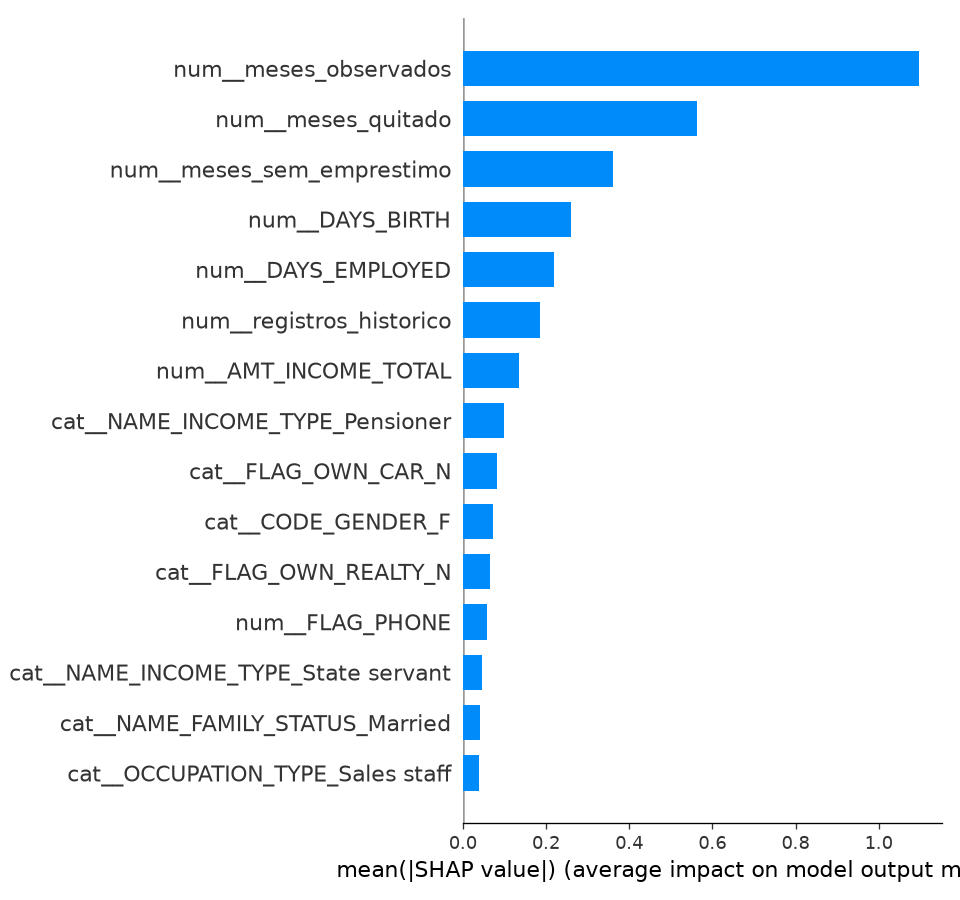

In [11]:
Image(filename='../resultados/shap_importancia_global.png')

## 26-27. Interpretação dos resultados e conclusões de negócio

In [12]:
from pathlib import Path
import pandas as pd

pasta_resultados = Path("../resultados")
tabela = pd.read_csv(pasta_resultados / "tabela_metricas.csv")
with open(pasta_resultados / "melhor_modelo.txt") as f:
    melhor_modelo = f.read().strip()
linha_melhor = tabela[tabela["modelo"] == melhor_modelo].iloc[0]

texto = f"""
=== ETAPA 26: INTERPRETACAO CONSOLIDADA ===

Modelo com melhor ROC-AUC no conjunto de teste: {melhor_modelo} (ROC-AUC = {linha_melhor['roc_auc']:.4f}).
Todos os 4 modelos treinados ficaram entre ROC-AUC 0.74 e 0.81 -- claramente acima do baseline
aleatorio (0.50) e do baseline ingenuo (DummyClassifier, que so acerta a classe majoritaria e
tem ROC-AUC 0.50 por definicao). Isso indica que existe sinal real nos dados, mas o problema
esta longe de ser "resolvido": a base e extremamente desbalanceada (98.31% bons pagadores,
1.69% com evidencia de atraso >= 30 dias), entao mesmo um recall de ~55-65% ainda erra uma
fracao relevante dos casos de risco (falsos negativos), e a precision baixa (4-7%) significa
que a maioria dos "alertas" do modelo, no threshold padrao de 0.5, sao falsos positivos.

Viés e variância: a Arvore de Decisao (max_depth=5) e a Regressao Logistica sao mais simples e
tendem a menos overfitting, mas tambem capturam menos padrao (ROC-AUC mais baixo). Random Forest
e XGBoost capturam relacoes nao-lineares melhor, ao custo de serem mais dificeis de auditar
individualmente (mitigado aqui com permutation importance + SHAP).

Estabilidade: a importancia de variaveis foi calculada com 10 repeticoes (permutation_importance,
n_repeats=10) e confirmada de forma independente pelo SHAP (TreeExplainer) -- as duas tecnicas,
usando metodos matematicos diferentes, concordam no ranking das variaveis mais importantes
(meses_observados, meses_quitado, meses_sem_emprestimo, DAYS_BIRTH), o que da mais confianca
de que nao e ruido de uma unica execucao.

LIMITACAO IMPORTANTE (achada nesta analise, nao e um problema teorico generico): a variavel mais
importante em ambas as tecnicas e "meses_observados" (quantos meses de historico o cliente tem
registrados). Isso e esperado pela propria definicao do target: um cliente observado por 60 meses
teve 60 chances de, em algum mes, cair em atraso >= 30 dias; um cliente observado por apenas 3
meses teve so 3 chances. Ou seja, parte do que o modelo aprende e "tempo de exposicao ao risco",
nao necessariamente "perfil de risco intrinseco" do cliente. Isso NAO e vazamento de dados (nao
usa informacao futura, e uma variavel legitimamente disponivel no momento da decisao), mas e uma
limitacao metodologica real que precisa ser comunicada: o modelo pode estar parcialmente
confundindo "cliente antigo" com "cliente arriscado".

Fairness/privacidade: CODE_GENDER e uma feature usada no modelo (aparece no SHAP). Isso levanta
uma questao de possivel viés discriminatorio que precisa de análise dedicada antes de qualquer
uso real (nao feita aqui, esta fora do escopo deste exercicio academico) -- calcular metricas de
erro separadas por genero e considerar remover a variavel ou aplicar tecnicas de fairness seria
o proximo passo antes de qualquer producao.

=== ETAPA 27: CONCLUSOES DE NEGOCIO ===

1. Evidencia: os 4 modelos superam claramente o baseline aleatorio (ROC-AUC 0.74-0.81 vs 0.50).
   Implicacao: o modelo tem valor como FERRAMENTA DE PRIORIZACAO -- ordenar solicitantes por
   probabilidade de risco pode ajudar um analista humano a decidir em quais pedidos investir mais
   tempo de análise manual, em vez de tratar todos os pedidos com a mesma prioridade.
   Limite: com precision de 4-7% no threshold padrao, usar o modelo para APROVACAO/REJEICAO
   AUTOMATICA geraria uma quantidade grande de recusas incorretas de bons pagadores (falsos
   positivos). Nao deve substituir decisao humana.

2. Evidencia: recall de ate ~65% (Regressao Logistica) significa que o modelo ainda deixa passar
   cerca de 1 em cada 3 clientes que de fato tiveram evidencia de risco no historico.
   Implicacao: mesmo como ferramenta de apoio, o modelo NAO elimina a necessidade de outros
   controles de risco (ex: analise de bureau de credito externo, score de terceiros).
   Limite: threshold de decisao (0.5) foi usado como ponto de partida didatico, nao foi otimizado
   para o custo real de negocio (quanto custa aprovar um mau pagador vs. quanto custa rejeitar um
   bom pagador) -- essa calibracao dependeria de dados de custo que nao fazem parte deste dataset
   academico.

3. Evidencia: a variavel dominante em importancia (meses_observados) reflete tempo de exposicao,
   nao necessariamente risco intrinseco (ver limitacao na Etapa 26).
   Implicacao: antes de qualquer uso real, vale reformular features para separar "tempo de conta"
   de "taxa de eventos de risco por unidade de tempo" (ex: eventos_risco por mes observado), com
   cuidado redobrado para nao reintroduzir o vazamento de dados ja identificado e corrigido nesta
   analise (a versao ingenua dessa normalizacao, feita e depois removida aqui, deu ROC-AUC=1.0
   artificial porque usava a mesma regra do target).

4. Evidencia: CODE_GENDER tem peso mensuravel nas previsoes (via SHAP).
   Implicacao: recomenda-se auditoria de fairness (metricas separadas por genero) antes de
   qualquer decisao real ser apoiada neste modelo.

CONCLUSAO GERAL: o modelo apoia PRIORIZACAO DE ANALISE, nao decisao automatica de credito. Nenhum
numero aqui deve ser lido como "o modelo aprova/rejeita corretamente X% dos casos" -- os numeros
sao os que saíram da execucao real desta pipeline, com o dataset academico fornecido, e tem as
limitacoes explicitas listadas acima.
"""

print(texto)
with open(pasta_resultados / "07_interpretacao_negocio.txt", "w", encoding="utf-8") as f:
    f.write(texto)



=== ETAPA 26: INTERPRETACAO CONSOLIDADA ===

Modelo com melhor ROC-AUC no conjunto de teste: xgboost (ROC-AUC = 0.8096).
Todos os 4 modelos treinados ficaram entre ROC-AUC 0.74 e 0.81 -- claramente acima do baseline
aleatorio (0.50) e do baseline ingenuo (DummyClassifier, que so acerta a classe majoritaria e
tem ROC-AUC 0.50 por definicao). Isso indica que existe sinal real nos dados, mas o problema
esta longe de ser "resolvido": a base e extremamente desbalanceada (98.31% bons pagadores,
1.69% com evidencia de atraso >= 30 dias), entao mesmo um recall de ~55-65% ainda erra uma
fracao relevante dos casos de risco (falsos negativos), e a precision baixa (4-7%) significa
que a maioria dos "alertas" do modelo, no threshold padrao de 0.5, sao falsos positivos.

Viés e variância: a Arvore de Decisao (max_depth=5) e a Regressao Logistica sao mais simples e
tendem a menos overfitting, mas tambem capturam menos padrao (ROC-AUC mais baixo). Random Forest
e XGBoost capturam relacoes nao-lineare